# VISUAL TRANSFORMER FOR IMAGE CLASSIFICATION
APPLICATION OF PAPER : AN IMAGE IS COMPOSED OF 16X16 WORDS

## **process flow**
1. load dataset
2. patch embedding
3. transformer encoder
4. MLP head
5. VISION TRANSFORMER CLASS
6. training loop
7. validation accuracy
8. prediction

* each patch is 768x1 dimension vector size

* lets say token space is 1024x1

* X= 1 X 768
* W = 768 X 1024
* Y= 1 X 1024
* B= 1024 X 1
THEN-> LINEAR PROJECTION LAYER
Y= W transpose X + B

#import necessary libraries

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms # image preprocessing example resize, normalize, convert image to tensors

import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

CIFAR-10:

60,000 color images (32×32 pixels), 10 classes (airplane, car, bird, cat, etc.)
Split: 50,000 training + 10,000 testing
Each image has 3 channels (RGB)

In [ ]:
from torchvision import datasets, transforms

# Define a transformer to convert images to tensors and normalize them
# The mean and standard deviation for CIFAR-10 are (0.5, 0.5, 0.5)
# for each channel, with a range of [-1, 1] after normalization.
''' old
transformation_operation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
'''
#new
#  Train transform (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(), #convert image to tensor and scales pixel from [0-255] to [0-> 1]
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) #normalize values to [-1,1]
])

#validation no augment
val_transform = transforms.Compose([
    transforms.ToTensor(),
    #Because images have 3 channels (R, G, B), so provide mean and std (0.5 each) for each channel separately.
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


# Load the CIFAR-10 training dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Load the CIFAR-10 test dataset, named as val_dataset as per your request
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation/test samples: {len(val_dataset)}")

Number of training samples: 50000
Number of validation/test samples: 10000


# DEFINE DATASET BATCHES

In [ ]:
# define variables
num_classes = 10
batch_size = 64
num_channels = 3
img_size = 32
patch_size = 4
num_patches = (img_size // patch_size) ** 2

# Model Architecture - Scaled for speed and accuracy
embedding_dim = 128      # High enough for color, low enough for speed
attention_heads = 4      # Sufficient for 32x32 images
transformer_blocks = 4   # Keeps the model from getting too heavy
mlp_hidden_nodes = 256   # Standard expansion for the MLP
learning_rate = 0.0005  #ols was 0.001
epochs = 25  #old was 15

* img_size = 32, patch_size = 4 → num_patches = 64
_
Image is split into small patches (like words in NLP).
32/4 = 8 → total patches = 8×8 = 64

*

In [ ]:
import torch.utils.data as dataloader
train_loader= dataloader.DataLoader(train_dataset,batch_size,shuffle=True) #64 images part of each batch
#old
val_loader= dataloader.DataLoader(val_dataset,batch_size, shuffle=True)

#new
val_loader = dataloader.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# **PART 1: PATCH EMBEDDING**

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, num_channels, embedding_dim):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            num_channels,
            embedding_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

# **PART 2: TRANSFORMER ENCODER**

In [ ]:
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1=nn.LayerNorm(embedding_dim)
    self.layer_norm2=nn.LayerNorm(embedding_dim)
    self.multihead_attention=nn.MultiheadAttention(embedding_dim,attention_heads, batch_first=True)
    #add dropout
    self.dropout=nn.Dropout(0.1)
    self.mlp=nn.Sequential(
        nn.Linear(embedding_dim,mlp_hidden_nodes),
        nn.GELU(),
        nn.Linear(mlp_hidden_nodes,embedding_dim)
    )

  def forward(self,x):
      #residual 1
    residual1= x
    x= self.layer_norm1(x)  #layer normalization

    x= x.transpose(0,1)
      #multiheaded attention

    x= self.multihead_attention(x,x,x)[0] # x is converted to query, key, value

    x= x.transpose(0,1)
      # residual was added
    x= residual1 + x


      #residual 2
    residual2= x
    x= self.layer_norm2(x)  #one more layer normalize
    x= self.mlp(x)  #mlp
    x= residual2+x  #one more residual added

    return x

# **PART 3: MLP HEAD**

In [ ]:
class MLP_head(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(embedding_dim)
        self.mlp_head = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        x = x.mean(dim=1)  # use mean pooling instead of class token
        x = self.layer_norm1(x)
        x = self.mlp_head(x)
        return x

# **TRANSFORMER CLASS**

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_channels, embedding_dim)

        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embedding_dim))

        self.encoder = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])

        self.mlp_head = MLP_head(embedding_dim, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)

        B = x.size(0)
        class_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((class_tokens, x), dim=1)

        x = x + self.position_embedding
        x = self.encoder(x)

        x = self.mlp_head(x)  # MLP handles pooling

        return x

## **TRAINING**

In [ ]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model =VisionTransformer().to(device)
optimizer= torch.optim.Adam(model.parameters(),lr=learning_rate)
criterion= nn.CrossEntropyLoss(  )

In [ ]:
# training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct_epoch = 0
    total_epoch = 0

    print(f"\nEpoch {epoch+1}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

        print(f"Epoch {epoch+1} | Batch {batch_idx+1}: Loss={loss.item():.4f}, Acc={accuracy:.2f}%")

    epoch_acc = 100.0 * correct_epoch / total_epoch
    print(f"==> Epoch {epoch+1}: Total Loss={total_loss:.4f}, Accuracy={epoch_acc:.2f}%")

Streaming output truncated to the last 5000 lines.
Epoch 19 | Batch 494: Loss=0.9232, Acc=71.88%
Epoch 19 | Batch 495: Loss=1.0662, Acc=64.06%
Epoch 19 | Batch 496: Loss=0.9605, Acc=70.31%
Epoch 19 | Batch 497: Loss=1.0939, Acc=64.06%
Epoch 19 | Batch 498: Loss=1.0402, Acc=65.62%
Epoch 19 | Batch 499: Loss=0.9803, Acc=65.62%
Epoch 19 | Batch 500: Loss=0.9387, Acc=64.06%
Epoch 19 | Batch 501: Loss=1.2024, Acc=59.38%
Epoch 19 | Batch 502: Loss=1.1544, Acc=54.69%
Epoch 19 | Batch 503: Loss=1.1083, Acc=62.50%
Epoch 19 | Batch 504: Loss=0.9765, Acc=71.88%
Epoch 19 | Batch 505: Loss=1.0737, Acc=57.81%
Epoch 19 | Batch 506: Loss=0.7263, Acc=82.81%
Epoch 19 | Batch 507: Loss=0.9516, Acc=57.81%
Epoch 19 | Batch 508: Loss=1.1550, Acc=60.94%
Epoch 19 | Batch 509: Loss=0.8517, Acc=64.06%
Epoch 19 | Batch 510: Loss=1.0500, Acc=64.06%
Epoch 19 | Batch 511: Loss=0.7665, Acc=73.44%
Epoch 19 | Batch 512: Loss=0.8023, Acc=67.19%
Epoch 19 | Batch 513: Loss=0.9481, Acc=62.50%
Epoch 19 | Batch 514: Loss=0.

50,000 training images ÷ 64 ≈ 782 batches per epoch

# **TESTING**

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100.0 * correct / total
print(f"VALIDATION Accuracy: {accuracy:.2f}%")

VALIDATION Accuracy: 68.65%


#**OLD RESULTS**
## TRAINING ACCURACY :  Epoch 15: Total Loss=604.4946, Accuracy=72.42%

## VALIDATION ACCURACY : 64.67 %

### overfitting

* to reduce overfitting we will add data augmentation i.e
---
* transformation_operation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
* and add dropout = 0.1 and learning rate 0.0005  
*and train longer i.e epochs =25  *and val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# **NEW RESULT**

* TRAIN ACCURACY-> 67.49%
* VALIDATION ACCURACY -> 68.65%
---
Validation > Training

1. Means no overfitting
2. augmentation + dropout are working
3. Model generalizes well

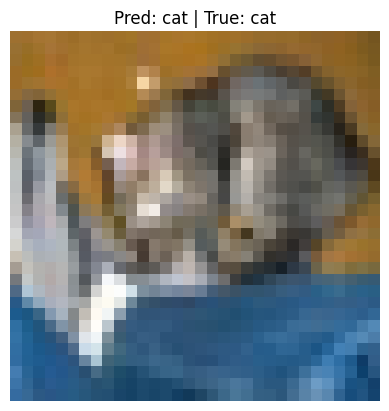

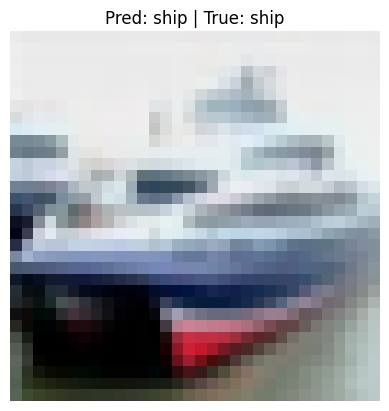

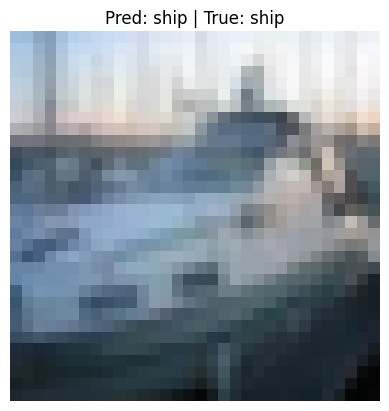

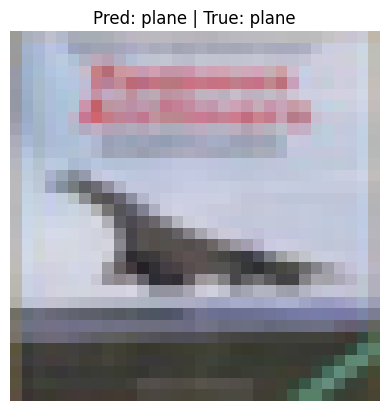

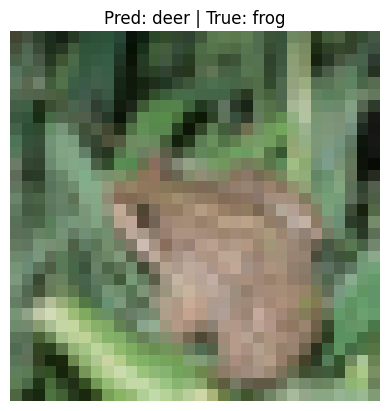

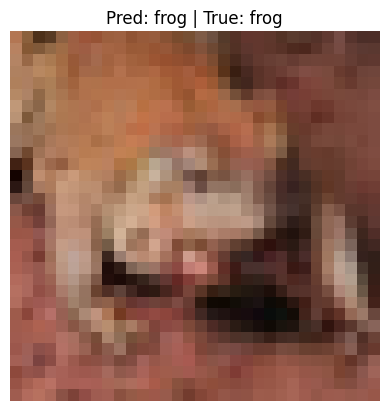

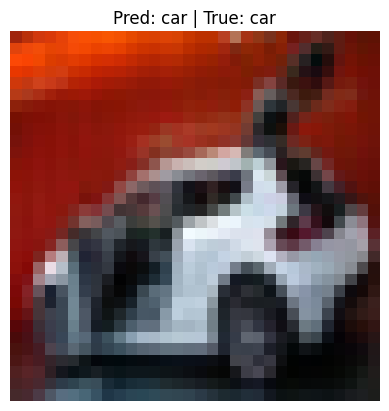

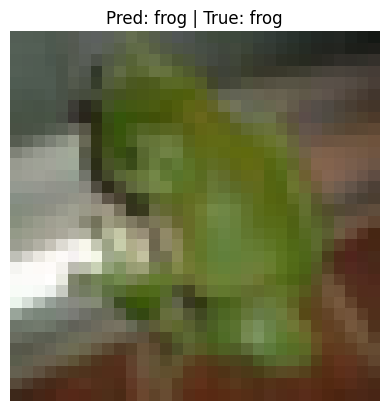

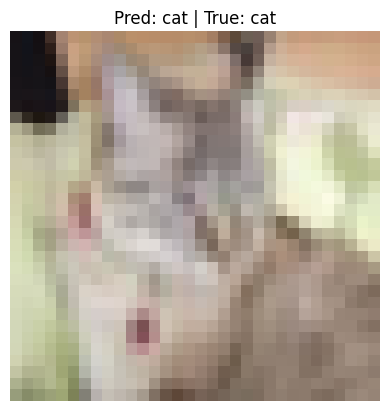

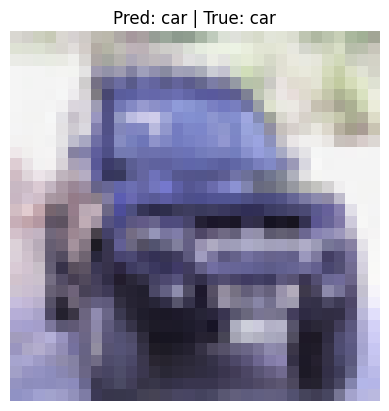

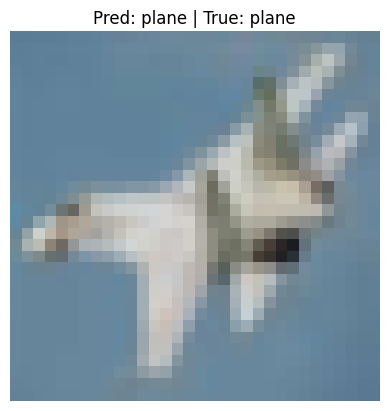

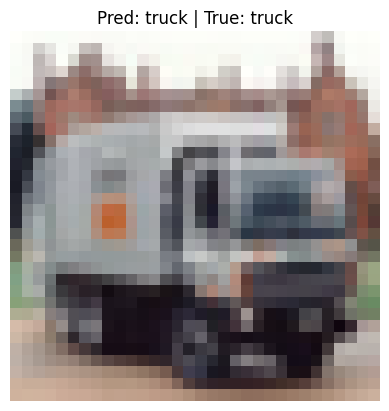

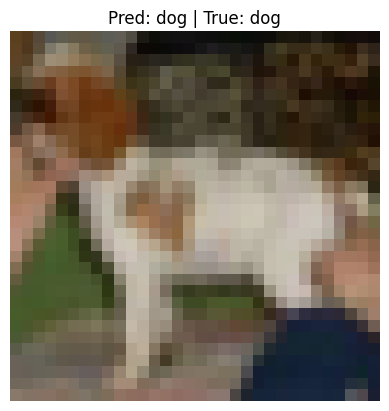

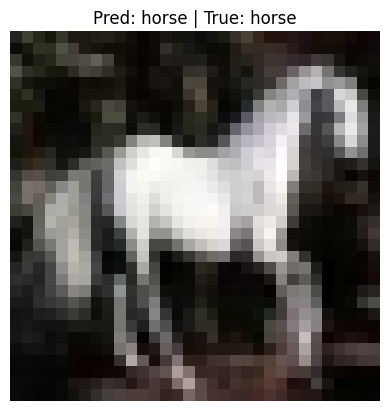

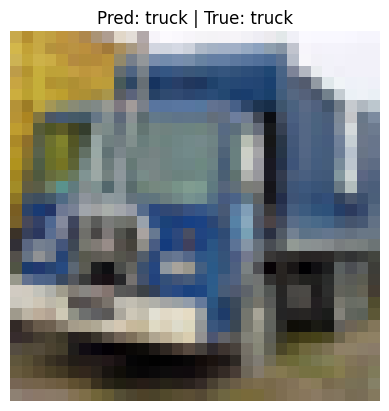

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
preds = outputs.argmax(dim=1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

# CIFAR-10 class names
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

for i in range(15):
    img = images[i] / 2 + 0.5  # unnormalize
    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Pred: {classes[preds[i]]} | True: {classes[labels[i]]}")
    plt.axis('off')
    plt.show()